### Cavity tracking pipeline
Uses linear fitting to the fin and MSERs to extract air cavity width and depth over time.

#### Import packages

In [1]:
import cv2
import numpy as np
from dataloader import MOVE
import os
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import matplotlib.cm as cm
import matplotlib.animation as animation
import scipy
from scipy.spatial import distance
from scipy.interpolate import BSpline, make_interp_spline
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy import signal
import seaborn as sns
import pandas as pd
import math

In [2]:
RANDOM_SAMPLE = False
WATERLINE = 0
COUNT = 0
PT1 = ()
PT2 = ()
DIST_SCALE = 1
FULLFIN = False

#### Helper functions

In [3]:
# either generates a random path, or uses a video that you choose

def generate_path(rando : bool) -> str:
    if rando==True:
        ROOT = os.path.dirname(os.getcwd())
        DATA_DIR = os.path.join(ROOT, 'data')
        FIN_DIR = os.path.join(DATA_DIR, random.choice(list(filter(lambda x: os.path.isdir(os.path.join(DATA_DIR, x)), os.listdir(DATA_DIR)))))
        vp = os.path.join(FIN_DIR, random.choice(list(filter(lambda x: os.path.splitext(x)[1]=='.mov', os.listdir(FIN_DIR)))))
    else:
        #vp = r"C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\From Crush\TH16ST25A2D1000TS0\TH16ST25A2D1000TS0_1.mov" # PIV processed
        #vp = r"C:\Users\aatid\Downloads\FILM\TH32ST50A1D250\TH32ST50A1D250TS0_1.mov"
        #vp = r'c:\Users\aatid\Downloads\FILM\TH16ST17A3D750\TH16ST17A3D750TS0_1.mov'
        vp = r"E:\TH32\TH32ST17A1D500\TH32ST17A1D500TS0_1.mov"
    print(vp)

    return vp

In [4]:
# some video helper functions - play two videos stacked vertically, play a series of frames that's not a MOVE object, or
# create a linear bounding box based on contours and overlay it onto an image

def compare_videos(frames1, frames2, crop = None, doubletime = False, slow = False, ultraslow = False):
    divider = 255 * np.ones_like(frames1[0])
    divider = divider[0:10]
    frames = []

    if len(frames1) != len(frames2):
        frames1 = frames1[:min([len(frames1), len(frames2)])]
        frames2 = frames2[:min([len(frames1), len(frames2)])]

    for i in range(len(frames1)):
        frame1 = frames1[i][:crop, :]
        frame2 = frames2[i][:crop, :]
        joined = np.concatenate((frame1, divider, frame2), axis = 0)
        frames.append(joined)
    
    for frame in frames:
            cv2.imshow("Video Frame", frame)
            if doubletime:
                if cv2.waitKey(12) & 0xFF == ord('q'):
                    break
            elif slow:
                if cv2.waitKey(40) & 0xFF == ord('q'):
                    break
            elif ultraslow:
                if cv2.waitKey(60) & 0xFF == ord('q'):
                    break
            else:
                if cv2.waitKey(25) & 0xFF == ord('q'):
                    break
                 
        
    cv2.destroyAllWindows()

def play_video(frames, doubletime=False, slow=False, ultraslow=False):
    for frame in frames:
        cv2.imshow("Video Frame", frame)
        if doubletime:
            if cv2.waitKey(12) & 0xFF == ord('q'):
                break
        elif slow:
            if cv2.waitKey(40) & 0xFF == ord('q'):
                break
        elif ultraslow:
            if cv2.waitKey(60) & 0xFF == ord('q'):
                break
        else:
            if cv2.waitKey(25) & 0xFF == ord('q'):
                break
                 
    cv2.destroyAllWindows()


# for waterline detection - when image is clicked, stores coordinates

def click_event(event, x, y, flags, param):
    global WATERLINE
    if event == cv2.EVENT_LBUTTONDOWN:
        WATERLINE = y
        cv2.destroyAllWindows()
        return
    else:
        return
    
def distance_calibration(event, x, y, flags, param):
    global DIST_SCALE
    global PT1
    global PT2
    global COUNT
    if event == cv2.EVENT_LBUTTONDOWN and COUNT == 0:
        DIST_SCALE = y
        PT1 = (x, y)
        COUNT = 1
        cv2.destroyAllWindows()
    elif event == cv2.EVENT_LBUTTONDOWN and COUNT == 1:
        DIST_SCALE = abs(y - DIST_SCALE)
        PT2 = (x, y)
        COUNT = 0
        cv2.destroyAllWindows()
    return

def get_points(event, x, y, flags, param):
    global PT1
    global PT2
    global COUNT
    if event == cv2.EVENT_LBUTTONDOWN and COUNT == 0:
        PT1 = (x, y)
        COUNT = 1
        cv2.destroyAllWindows()
    elif event == cv2.EVENT_LBUTTONDOWN and COUNT == 1:
        PT2 = (x, y)
        COUNT = 0
        cv2.destroyAllWindows()
    return
    

# given 2 bounding boxes, b and a, return whether b is in a

def isin(a, b):
    if a[0] <= b[0] and a[1] <= b[1]:
            if (a[0] + a[2]) >= (b[0] + b[2]):
                if (a[1] + a[3]) >= (b[1] + b[3]):
                    return True
    return False


# overlay bounding boxes frame by frame onto a video
def bbox_overlay(video, bboxes, vert_offset=0, color=(244, 255, 41), width=1):
    for i in range(len(video.frames)):
        frame = video.frames[i]
        for bbox in bboxes[i]:
            if len(bbox) > 0:
                x, y, w, h = bbox
                cv2.rectangle(frame, (x, y + vert_offset), (x + w, y + vert_offset + h), color, width)

    return video

# takes lowpass filtered data, separates it into strokes and smooths each stroke
# offset counters horizontal offset introduced by lowpass filter
def smooth_by_stroke(data, offset, sig=2, rad=3):
    strokes = []
    current_stroke = []
    in_stroke = False

    for pt in range(len(data)):
        if data[pt] > 0:
            if in_stroke:
                current_stroke.append(data[pt])
            else:
                strokes.append(current_stroke)
                current_stroke = [data[pt]]
                in_stroke = True
        else:
            if in_stroke:
                strokes.append(current_stroke)
                current_stroke = [0]
                in_stroke = False
            else:
                current_stroke.append(0)
    strokes.append(current_stroke)

    for stroke in range(len(strokes)):
        strokes[stroke] = gaussian_filter1d(strokes[stroke], sigma=sig, radius=rad)

    smoothed_data = []
    for stroke in range(len(strokes)):
        for i in range(len(strokes[stroke])):
            smoothed_data.append(strokes[stroke][i])

    smoothed_data = smoothed_data[offset:] + [0] * offset

    return smoothed_data

# convers mser "coordinate pairs" structure into array
def mser_to_array(mser, frame_like, bbox=[]):
    frame = np.zeros_like(frame_like)
    for point in mser:
        col, row = point
        frame[row][col] = 255
    if len(bbox) > 0:
        x, y, w, h = bbox
        cv2.rectangle(frame, (x, y), (x + w, y + h), 255, 1)
    return frame

# takes in msers and bboxes for a video, returns air cavity width and depth for every frame
def params_by_frame(msers, bboxes, fitfunc, params, frame_like, display=False, display_fwhm=False, display_vid=None):
    left_widths = []
    left_depths = []
    left_fwhm = []
    right_widths = []
    right_depths = []
    right_fwhm = []

    b = params[-1]
    params = np.transpose(params)

    for frame in range(len(bboxes)):
        fin_center = int(b[frame])
        
        left_leftmost = fin_center
        left_rightmost = -1
        left_depth = -1

        right_leftmost = fin_center
        right_rightmost = -1
        right_depth = -1

        for i in range(len(bboxes[frame])):
            x, y, w, h = bboxes[frame][i]
            if (x + w) <= fin_center:
                left_leftmost = min(left_leftmost, x)
                left_rightmost = max(left_rightmost, x + w)
                left_depth = max(left_depth, y + h)
            elif x >= fin_center:
                right_leftmost = min(right_leftmost, x)
                right_rightmost = max(right_rightmost, x + w)
                right_depth = max(right_depth, y + h)
            else:
                left_leftmost = min(left_leftmost, x)
                left_rightmost = max(left_rightmost, fin_center)
                right_rightmost = max(right_rightmost, x + w)
                right_leftmost = min(right_leftmost, fin_center)

                if (y + h) > left_depth or (y + h) > right_depth:
                    mser = mser_to_array(msers[frame][i], frame_like)
                    found_left = False
                    found_right = False
                    row = y + h
                    while ((not found_left) or (not found_right)) and (row > min(left_depth, right_depth)):
                        center = int(fitfunc(row, *params[frame]))
                        if 255 in mser[row][:center] and (not found_left):
                            left_depth = max(left_depth, row)
                            found_left = True
                        if 255 in mser[row][center:] and (not found_right):
                            right_depth = max(right_depth, row)
                            found_right = True
                        row -= 1
        mser_img = []
        for mser in msers[frame]:
            mser_img.append(mser_to_array(mser, frame_like))
        mser_frame = np.zeros_like(frame_like)
        if len(mser_img) > 0:
            mser_frame = mser_img[0]
            for mser in mser_img:
                mser_frame = cv2.bitwise_or(mser_frame, mser)

        if left_depth > 0:
            lhm = int(left_depth / 2)
            col = int(fitfunc(lhm, *params[frame]))
            lcount = 0
            lfirst = col
            ended = False
            while not ended and col >= 0 and col < frame_like.shape[1]:
                if mser[lhm][col] == 255:
                    if lcount == 0:
                        lfirst = col
                    lcount += 1
                elif lcount > 0:
                    ended = True
                col -= 1
            left_fwhm.append(lcount)
        else:
            left_fwhm.append(0)
        
        if right_depth > 0:
            rhm = int(right_depth / 2)
            col = int(fitfunc(rhm, *params[frame]))
            count = 0
            rfirst = col
            ended = False
            while not ended and col >= 0 and col < frame_like.shape[1]:
                if mser[rhm][col] == 255:
                    if count == 0:
                        rfirst - col
                    count += 1
                elif count > 0:
                    ended = True
                col += 1
            right_fwhm.append(count)
        else:
            right_fwhm.append(0)


        if display:
            # left side parameters
            if (left_rightmost - left_leftmost) > 5:
                cv2.line(display_vid.frames[frame], (left_leftmost, 1), (left_rightmost, 1), (255, 200, 71), 2)
                mid_left = int((left_leftmost + left_rightmost) / 2)
                cv2.line(display_vid.frames[frame], (mid_left, 0), (mid_left, left_depth), (255, 200, 71), 2)
                if display_fwhm:
                    cv2.line(display_vid.frames[frame], (max(0, (lfirst - left_fwhm[-1])), lhm), (lfirst, lhm), (255, 200, 71), 2)

            # right side parameters
            if (right_rightmost - right_leftmost) > 5:
                cv2.line(display_vid.frames[frame], (right_leftmost, 1), (right_rightmost, 1), (71, 160, 255), 2)
                mid_right = int((right_leftmost + right_rightmost) / 2)
                cv2.line(display_vid.frames[frame], (mid_right, 0), (mid_right, right_depth), (71, 160, 255), 2)
                if display_fwhm:
                    cv2.line(display_vid.frames[frame], (rfirst, rhm), (min(frame_like.shape[1], (rfirst + right_fwhm[-1])), rhm), (71, 160, 255), 2)
            
        left_widths.append(left_rightmost - left_leftmost)
        if (left_rightmost - left_leftmost) > 5:
            left_depths.append(left_depth)
        else:
            left_depths.append(0)
        right_widths.append(right_rightmost - right_leftmost)
        if (right_rightmost - right_leftmost) > 5:
            right_depths.append(right_depth)
        else:
            right_depths.append(0)
    
    return (left_widths, left_depths, left_fwhm, right_widths, right_depths, right_fwhm)
    
# genuinely just a matplotlib wrapper
def plot(x, y, labels, colors, x_label="", y_label="", title="", show=True):
    if isinstance(y[0], list) or isinstance(y[0], np.ndarray):
        for data in zip(y, labels, colors):
            y0, label, color = data
            plt.plot(x, y0, color=color, label=label)
    else:
        plt.plot(x, y, labels, colors)
    plt.legend()
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    if show:
        plt.show()

# given some frame n in video 1, returns the frame that will fall at the same time in video 2
def fr1_to_fr2(n, framerate1, framerate2, p1, p2):
    scaling = n * framerate2 / framerate1
    offset = p2 - (p1 * framerate2 / framerate1)
    return int(scaling + offset)

def calibrate(data, fullfin=False, dim=1, return_time=False, times_width=False, unit='mm'):
    timescale = 1/500

    if isinstance(data[0], list) or isinstance(data[0], np.ndarray):
        time = timescale * np.arange(len(data[0]))
    else:
        time = timescale * np.arange(len(data))
    
    data = np.array(data)
    if unit == 'cm':
        data = data / (10**dim)
    elif unit == 'm':
        data = data / (1000**dim)
    if times_width:
        data = 50 * data
        dim = dim - 1

    if fullfin:
        lenscale = (100/DIST_SCALE)**dim
    else:
        lenscale = (10/DIST_SCALE)**dim
    data = lenscale * data
    
    if return_time:
        return time, data
    else:
        return data

def wave_removal(frame, msers, bboxes, fitfunc, params, smoothstr = 4, hthresh = 100, vthresh = 5, cthresh=50):
    flatframe = np.zeros(shape=(frame.shape[0], frame.shape[1]))
    if len(msers) > 0:
        mser_frame = mser_to_array(msers[0], flatframe)
        for i in range(len(msers)):
            temp_frame = mser_to_array(msers[i], flatframe)
            #MOVE.show(temp_frame)
            mser_frame = cv2.bitwise_or(mser_frame, temp_frame)
        mser_frame = mser_frame.astype(np.uint8)
    
        newframe = np.zeros_like(frame)
        contours, hierarchy = cv2.findContours(mser_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        newframe = cv2.drawContours(newframe, contours, -1, (255, 255, 255), 1)
    
        #cv2.line(newframe, (center, 0), (center, 400), (255, 0, 0), 1)
        #MOVE.show(newframe)

        maxy = bboxes[0][1] + bboxes[0][3]
        if len(bboxes) > 1:
            for i in range(1, len(bboxes)):
                if (bboxes[i][1] + bboxes[i][3]) > maxy:
                    maxy = bboxes[i][1] + bboxes[i][3]

        x = []
        y = []
        for col in range(newframe.shape[1]):
            row = maxy
            found = False
            while row >= 0 and not found:
                if newframe[row][col] == 255:
                    found = True
                    x.append(col)
                    y.append(row)           
                row -= 1
        
        lx = []
        ly = []
        rx = []
        ry = []
        center = int(fitfunc(50, *params))
        for i in range(len(x)):
            if x[i] <= (center - hthresh):
                lx.append(x[i])
                ly.append(y[i])
            elif x[i] >= (center + hthresh):
                rx.append(x[i])
                ry.append(y[i])
        #MOVE.show(newframe)

        for i in range(smoothstr):
            ly = gaussian_filter1d(ly, sigma=2, radius=2)
            ly = gaussian_filter1d(ly, sigma=3, radius=5)
            ly = gaussian_filter1d(ly, sigma=4, radius=8)
            ry = gaussian_filter1d(ry, sigma=2, radius=2)
            ry = gaussian_filter1d(ry, sigma=3, radius=5)
            ry = gaussian_filter1d(ry, sigma=4, radius=8)

        # newframe = np.zeros_like(newframe)
        # for i in range(len(lx)):
        #     newframe[ly[i]][lx[i]] = 255
        # for i in range(len(rx)):
        #     newframe[ry[i]][rx[i]] = 255

        lcutoff = 0
        lsave = 0
        if len(ly) > 1:
            index = len(ly) - 1
            lymin = ly[index]
            lconst = 0
            lcount = 0
            while lcutoff < 1 and index >= 0:
                if ly[index] < lymin:
                    lymin = ly[index]
                    lcount = 0
                elif ly[index] - lymin > vthresh:
                    lcutoff = index
                    lsave = lx[lcutoff]
                if abs(ly[index] - lconst) < 3:
                    lcount += 1
                else:
                    lconst = ly[index]
                    lcount = 0
                if lcount > cthresh:
                    lcutoff = index + cthresh
                    lsave = lx[lcutoff]
                index -= 1
        ly = ly[lcutoff:]
        lx = lx[lcutoff:]

        rcutoff = -1
        rsave = frame.shape[1]
        if len(ry) > 1:
            index = 0
            rymin = ry[index]
            rconst = 0
            rcount = 0
            while rcutoff < 0 and index < len(ry):
                if ry[index] < rymin:
                    rymin = ry[index]
                    rcount = 0
                elif ry[index] - rymin > vthresh:
                    rcutoff = index
                    rsave = rx[rcutoff]
                if abs(ry[index] - rconst) < 3:
                    rcount += 1
                else:
                    rconst = ry[index]
                    rcount = 0
                if rcount > cthresh:
                    rcutoff = index - cthresh
                    rsave = rx[rcutoff]
                index += 1
        ry = ry[:rcutoff]
        rx = rx[:rcutoff]

        cavity_msers = []
        wave_msers = []

        maxy = 0
        for bbox in bboxes:
            maxy = max(maxy, bbox[1] + bbox[3])
        
        for mser in msers:
            temp_cavity = []
            temp_wave = []
            for point in mser:
                if point[0] < lsave or point[0] > rsave:
                    temp_wave.append(point)
                else:
                    temp_cavity.append(point)
            cavity_msers.append(temp_cavity)
            wave_msers.append(temp_wave)
        
        # newframe = np.zeros_like(frame)
        # for mser in cavity_msers:
        #     for point in mser:
        #         newframe[point[1], point[0]] = 255

        cavity_bboxes = []
        
        # for i in range(len(msers)):
        #     temp_cavity = []
        #     temp_wave = []
        #     if len(msers[i]) > 0:
        #         for point in msers[i]:
        #             if point[0] < lcutoff or point[0] > rcutoff:
        #                 temp_wave.append(point)
        #             else:
        #                 temp_cavity.append(point)
        #     cavity_msers.append(temp_cavity)
        #     wave_msers.append(temp_wave)
        # print(len(cavity_msers), len(cavity_msers[0]))
        
        j = 0
        while j < len(cavity_msers):
            mser = cavity_msers[j]
            if len(mser) > 0:
                minx = mser[0][0]
                maxx = mser[0][0]
                miny = mser[0][1]
                maxy = mser[0][1]
                for point in mser:
                    if point[0] < minx:
                        minx = point[0]
                    elif point[0] > maxx:
                        maxx = point[0]
                    if point[1] < miny:
                        miny = point[1]
                    elif point[1] > maxy:
                        maxy = point[1]
                temp_bbox = [minx, miny, maxx - minx, maxy - miny]
                cavity_bboxes.append(temp_bbox)
            else:
                cavity_msers.pop(j)
                j -= 1
            j += 1
            
        # newframe = np.zeros_like(newframe)
        # cv2.line(newframe, (lcutoff, 0), (lcutoff, 400), color=(0, 255, 0))
        # cv2.line(newframe, (rcutoff, 0), (rcutoff, 400), color=(0, 255, 0))
        # for i in range(len(cavity_bboxes)):
        #     x, y, w, h = cavity_bboxes[i]
        #     cv2.rectangle(newframe, (x, y), (x + w, y + h), color=255, thickness=1)
        #MOVE.show(newframe)

        return (cavity_msers, cavity_bboxes, wave_msers)
    else:
        return ([], [], [])
    
def linfit(x, a, b):
    return a*x + b

def sinfit(x, a, b, c):
    return a * np.sin(b * x) + c

def cosfit(x, a, b, c, d):
    return a * np.cos(b * x + c) + d

def slopefit(x, a):
    return a * x

def quartfit(x, a, b, c, d, e):
    return a*np.power(x, 4) + b*np.power(x, 3) + c*np.power(x,2) + d*np.power(x, 1) + e

def linpotfit(x, a, b, c):
    x = (x + b).astype(np.uint)
    return a * linpot[x] + c

def lin_to_cos(keyframes, a, b, max_x, min_x, frame_start, frame_end, slope_only=False):
    amp = (max_x - min_x + 80) / 2
    shift = (max_x + min_x) / 2
    freq = (2 * math.pi) / (frame_end - frame_start)
    timeshift = (2 * math.pi * frame_start) / (frame_end - frame_start)

    fake_sigma = 5 * np.ones_like(keyframes)
    (a_params, acov) = curve_fit(cosfit, keyframes, a, p0=[1, freq, timeshift, 0], sigma=fake_sigma, absolute_sigma=True)
    if not slope_only:
        (b_params, bcov) = curve_fit(cosfit, keyframes, b, p0=[amp, freq, timeshift, shift], sigma=fake_sigma, absolute_sigma=True)

    frames = np.arange(len(cropped.frames))
    a = cosfit(frames, *a_params)
    if not slope_only:
        b = cosfit(frames, *b_params)

    if slope_only:
        return a
    return (a, b)

def failmode(active_frame, fitfunc, power):
    global PT1
    global PT2
    global COUNT
    x = []
    y = []

    # first segment
    cv2.imshow("Click top of fin.", active_frame)
    cv2.setMouseCallback("Click top of fin.", get_points)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    cv2.circle(active_frame, (PT1[0], PT1[1]), 2, (255, 255, 255), 2)
    x.append(PT1[1])
    y.append(PT1[0])

    for point in range(power):
        COUNT = 0
        cv2.imshow("Click next line or bottom of fin.", active_frame)
        cv2.setMouseCallback("Click next line or bottom of fin.", get_points)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        cv2.circle(active_frame, (PT1[0], PT1[1]), 2, (255, 255, 255), 2)

        x.append(PT1[1])
        y.append(PT1[0])
    
    yerr = 5 * np.ones_like(y)
    (popt, pcov) = curve_fit(fitfunc, x, y, sigma=yerr, absolute_sigma=True)
    
    return popt

def contact_area_by_frame(msers, fitfunc, params, framelike, display=False, display_vid=None, display_color=(255, 222, 105)):
    left_areas = []
    right_areas = []

    b = params[-1]
    params = np.transpose(params)

    for frame in range(len(msers)):
        r_contact_area = 0
        l_contact_area = 0

        mser_mask = np.zeros_like(framelike)
        for item in msers[frame]:
            temp = mser_to_array(item, framelike)
            mser_mask = cv2.bitwise_or(temp, mser_mask)
        
        for row in range(framelike.shape[0]):
            fin_center = int(fitfunc(row, *params[frame]))

            looking = True
            for col in range(fin_center, fin_center + 25):
                if col > 0 and col < framelike.shape[1]:
                    if any(mser_mask[row][col]) > 0 and looking:
                        r_contact_area += 1
                        looking = False
            
            looking = True
            for col in range(fin_center, fin_center - 25, -1):
                if col > 0 and col < framelike.shape[1]:
                    if any(mser_mask[row][col]) > 0 and looking:
                        l_contact_area += 1
                        looking = False
        
        if display:
            center = int(b[frame])
            cv2.line(display_vid.frames[frame], (center + 15, 0), (center + 15, r_contact_area), display_color, thickness=2)
            cv2.line(display_vid.frames[frame], (center - 15, 0), (center - 15, l_contact_area), display_color, thickness=2)

        left_areas.append(l_contact_area)
        right_areas.append(r_contact_area)

    return left_areas, right_areas

def get_mser_edge(msers, bboxes, frame_like, bounds=[]):
    edges_by_frame = []

    maxy = 0
    for frame in bboxes:
        for bbox in frame:
            maxy = max(bbox[1] + bbox[3], maxy)

    maxlen = 0
    for f in range(len(msers)):
        frame = msers[f]
        edge = [[], []]

        frame_mser = np.zeros_like(frame_like)
        if len(frame) > 0:
            frame_mser = mser_to_array(frame[0], frame_like)
        for mser in frame:
            frame_mser = cv2.bitwise_or(frame_mser, mser_to_array(mser, frame_like))

        contours, hierarchy = cv2.findContours(frame_mser, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        for contour in contours:
            for point in contour:
                edge[0].append(point[0][0])
                edge[1].append(point[0][1])
        maxlen = max(maxlen, len(edge[0]))
        edges_by_frame.append(edge)
    
    for frame in edges_by_frame:
        while len(frame[0]) < maxlen:
            frame[0].append(-1)
            frame[1].append(-1)
    
    return edges_by_frame    

def mm_convert(data, pxmm1, px1, mm2, neg=False):
    data = (data - px1) * (1/pxmm1)
    if neg:
        return -1*data + mm2
    return data + mm2       

    

#### Load video & crop

In [5]:
# video loading
vid_path = generate_path(False)
recording = MOVE(vid_path)
unedited = recording.copy()
#play_video(recording)

E:\TH32\TH32ST17A1D500\TH32ST17A1D500TS0_1.mov


In [6]:
savedir = ""
while True:
    savedir = savedir + vid_path[0:(vid_path.index("\\") + 1)]
    vid_path = vid_path[(vid_path.index("\\") + 1):]
    if not "\\" in vid_path:
        case_name = vid_path[:vid_path.index(".")]
        break
print(case_name)
print(savedir)

TH32ST17A1D500TS0_1
E:\TH32\TH32ST17A1D500\


In [8]:
# get distance calibration scale
COUNT = 0 # do not change

frame = recording.frames[5].copy()[200:]

cv2.imshow("Click top of marker or bottom of screw.", frame)
cv2.setMouseCallback("Click top of marker or bottom of screw.", distance_calibration)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.circle(frame, (PT1[0], PT1[1]), 2, (66, 245, 81), 3)
print(PT1)

marker = input("Markers visible? [y / n] ")
if marker != 'y':
    FULLFIN = True
    cv2.imshow("Click bottom of fin.", frame)
    cv2.setMouseCallback("Click bottom of fin.", distance_calibration)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    cv2.circle(frame, (PT2[0], PT2[1]), 2, (66, 245, 81), 3)
    print(PT2)
else:
    FULLFIN = False
    dists = []
    for i in range(4):
        cv2.imshow("Click top of next marker.", frame)
        cv2.setMouseCallback("Click top of next marker.", distance_calibration)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        if i % 2 == 0:
            cv2.circle(frame, (PT2[0], PT2[1]), 2, (66, 245, 81), 3)
        else:
            cv2.circle(frame, (PT1[0], PT1[1]), 2, (66, 245, 81), 3)
        dists.append(abs(PT1[1] - PT2[1]))
    DIST_SCALE = sum(dists) / len(dists)

cv2.imshow("Marker location display.", frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

if FULLFIN:
    px_mm_cal = DIST_SCALE / 100
else:
    px_mm_cal = DIST_SCALE / 10
print(px_mm_cal)

(578, 133)
(584, 511)
3.78


In [9]:
# find waterline (with user input) and crop below waterline

# ----- PARAMS TO CHANGE -----
ALPHA = 1
BETA = -10
# ----------------------------


recording.to_gray(inplace=True)

background = recording.get_avg()
background = cv2.GaussianBlur(background, (1111, 1), sigmaX=32000, borderType=cv2.BORDER_REFLECT)

Z = np.float32(background.reshape((-1, 3)))

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
quantized = centers[labels.flatten()]
quantized = quantized.reshape(background.shape)

cv2.imshow("Click on waterline.", quantized)
cv2.setMouseCallback("Click on waterline.", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()
print(WATERLINE)

cropped = recording.crop(row_start = WATERLINE)
#play_video(cropped.frames, doubletime=True)


# binarize image
dupe = cropped.copy()
dupe = dupe.change_contrast(alpha=ALPHA, beta=BETA, inplace=False)
dupe.remove_avg(skipframes=100)
binary:MOVE = dupe.ranger(minval=50, maxval=240)
binary.median_blur(inplace=True)
play_video(binary, doubletime=True)

537


#### Fin tracking & masking

In [13]:
# remove the fin to use as mask

# ----- PARAMS TO CHANGE -----
REMOVAL_KSIZE = (3, 14)
# ----------------------------

fin_removed = binary.copy()
fin_removed = fin_removed.fin_removal(ksize=REMOVAL_KSIZE)
fin_removed = fin_removed.dilate(kernel=cv2.MORPH_RECT, ksize=(4, 4))
fin_removed = fin_removed.hole_filler()
play_video(fin_removed, doubletime=True)

In [14]:
# retrieve the fin and play video

# ----- PARAMS TO CHANGE -----
RETRIEVAL_KSIZE = (3, 16)
# ----------------------------

curve_retrieved = binary.copy()
curve_retrieved = curve_retrieved.fin_retrieval(horiz_ksize=RETRIEVAL_KSIZE, vert_ksize = (3, 3))
fin_contoured = curve_retrieved.contouring(thresholding=False, checkmode=True, topn=1, px_thresh=15, topbound=30)
play_video(fin_contoured, doubletime=True)

use_auto = '-'
while use_auto != 'y' and use_auto != 'n':
    use_auto = input("Is this contouring good enough to use for an automatic fit? Contour should follow the fin for nearly all frames and be longer than wide. [y/n] ")

In [15]:
# create linear or quartic mask
fitfunc = 0
params = []
power = input("Linear fit? [y / n] ")
if use_auto == 'y' and power == 'y':
    a, b, lowest_point = fin_contoured.lin_tracking()
    output_frames, display_frames = cropped.create_lin_mask(fin_removed, a, b, lowest_point, 15, display = True)
    params = np.array([a, b])
    fitfunc = linfit
elif power == 'y':
    numbered = cropped.copy()
    for i in range(len(numbered.frames)):
        cv2.putText(numbered.frames[i], "Frame " + str(i), (1000, 300), cv2.FONT_HERSHEY_PLAIN, 1, 0, 2)

    play_vid = input("Play video to determine first period? [y / n] ")
    if play_vid == 'y':
        play_video(numbered.frames[0:int(len(numbered.frames)/3)], ultraslow=True)
    frame_start = int(input("What was the first frame that the fin moved? "))
    frame_end = int(input("What was the end of the first period? "))

    keyframes = np.linspace(frame_start, frame_end, 7)
    extended = [frame_end + 20, frame_end + 60, frame_end + 100, frame_end + 150, frame_end + 200, frame_end + 250, frame_end + 300]
    keyframes = np.concatenate([keyframes, extended]).astype(np.uint)

    a_list = []
    b_list = []
    min_x = 1200
    max_x = 0
    for frame in keyframes:
        COUNT = 0
        active_frame = cropped.frames[frame].copy()[:150]
        cv2.imshow("Click top of fin.", active_frame)
        cv2.setMouseCallback("Click top of fin.", get_points)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        cv2.circle(active_frame, (PT1[0], PT1[1]), 2, (255, 255, 255), 2)
        if PT1[0] < min_x:
            min_x = PT1[0]
        if PT1[0] > max_x:
            max_x = PT1[0]

        cv2.imshow("Click bottom of fin.", active_frame)
        cv2.setMouseCallback("Click bottom of fin.", get_points)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        x = [PT1[1], PT2[1]]
        y = [PT1[0], PT2[0]]
        yerr = [5, 5]
        (popt, pcov) = curve_fit(linfit, x, y, sigma=yerr, absolute_sigma=True)
        a = popt[0]
        a_list.append(a)
        b = popt[1]
        b_list.append(b)

# applying linear mask
if use_auto != 'y' or power != 'y':
    if use_auto != 'y':
        (save_a, save_b) = lin_to_cos(keyframes, a_list, b_list, max_x, min_x, frame_start, frame_end)
        output_frames, display_frames = cropped.create_lin_mask(fin_removed, save_a, save_b, 350, 20, display=True, display_vid=cropped, display_color = (0, 0, 0))
        params = np.array([save_a, save_b])
        fitfunc = linfit
    else:
        params, lowest_point = fin_contoured.quart_tracking(failmode, seed=True, asymp_thresh=2)
        output_frames, display_frames = cropped.create_quad_mask(fin_removed, params, quartfit, lowest_point, 12, display=True)
        fitfunc = quartfit

params2 = np.transpose(params)
lin_mask = MOVE(frames=output_frames)
lin_masked = dupe.bitwise_and(lin_mask)
lin_masked = MOVE(frames=lin_masked)
lin_masked = lin_masked.median_blur(ksize=5)


In [16]:
play_video(display_frames, doubletime=True)

#### MSER tracking

In [17]:
# construct MSER object
mser = cv2.MSER_create(delta = 5, min_area = 100, max_area = 30000)

In [18]:
# apply mser tracking to masked video

# ----- PARAMS TO CHANGE -----
VERT_THRESHOLD = 0.3
AREA_THRESHOLD = 0.05
# ----------------------------

(lin_msers_display, lin_bboxes, lin_msers) = lin_masked.mser_track(mser=mser, vert_threshold=VERT_THRESHOLD, area_threshold=AREA_THRESHOLD)

In [19]:
# display tracked bounding boxes
overlay = unedited.copy()
overlay = overlay.crop(row_start=WATERLINE)
overlay2 = overlay.copy()
overlay = bbox_overlay(overlay, lin_bboxes, color=(255, 255, 255), width=2)
play_video(overlay, doubletime=True)

HTHRESH = 0
VTHRESH = 0

In [21]:
# wave removal, if necessary
# if the bounding boxes go all the way to the edges of the frame, probably necessary

# ----- PARAMS TO CHANGE -----
HTHRESH = 200
VTHRESH = 10
# ----------------------------

cav_msers = []
cav_bboxes = []
for i in range(len(lin_masked.frames)):
    (frame_msers, frame_bboxes, wave_msers) = wave_removal(lin_masked.frames[i], lin_msers[i], lin_bboxes[i], fitfunc, params2[i], smoothstr=10, hthresh=HTHRESH, vthresh=VTHRESH)
    cav_msers.append(frame_msers)
    cav_bboxes.append(frame_bboxes)

In [22]:
# display tracked bounding boxes, compare with/without wave removal
overlay2 = bbox_overlay(overlay2, cav_bboxes, color=(255, 255, 255), width=2)
compare_videos(overlay.frames, overlay2.frames, crop=375)

wrem = input("Use this wave removal? [y / n]")
if wrem == 'y':
    lin_msers = cav_msers
    lin_bboxes = cav_bboxes
else:
    HTHRESH = 0
    VTHRESH = 0

#### Parameter extraction & processing

In [23]:
# get cavity width and depth parameters
display_vid = unedited.copy()
display_vid = display_vid.crop(row_start=WATERLINE)
display_vid2 = display_vid.copy()
display_vid = bbox_overlay(display_vid, lin_bboxes, color=(255, 255, 255))

(left_widths, left_depths, left_fwhm, right_widths, right_depths, right_fwhm) = params_by_frame(lin_msers, lin_bboxes, fitfunc, params, lin_masked.frames[0], display=True, display_vid=display_vid, display_fwhm=False)

sos = signal.butter(10, 20, fs=len(left_depths), output='sos')
time, unfiltered = calibrate([left_widths, right_widths, left_depths, right_depths], fullfin=FULLFIN, return_time=True)
filtered = []
for data in unfiltered:
    filtered_data = signal.sosfilt(sos, data)
    filtered_data = smooth_by_stroke(filtered_data, 20, sig=4, rad=12)
    filtered_data = smooth_by_stroke(filtered_data, 20, sig=1, rad=3)
    filtered.append(filtered_data)

left_widths = filtered[0]
right_widths = filtered[1]
left_depths = filtered[2]
right_depths = filtered[3]

unfiltered = np.array(unfiltered).reshape((2, 2, -1))
filtered = np.array(filtered).reshape((2, 2, -1))

In [24]:
play_video(display_vid, slow=True)

In [25]:
# get fin/cavity contact area parameters
left_areas, right_areas = contact_area_by_frame(lin_msers, fitfunc, params, framelike=display_vid.frames[0], display=True, display_vid=display_vid2)
left_areas = gaussian_filter1d(left_areas, sigma=2, radius=2)
right_areas = gaussian_filter1d(right_areas, sigma=2, radius=2)
#play_video(display_vid)
contact_areas = calibrate([left_areas, right_areas], fullfin=FULLFIN, return_time=False)

In [26]:
play_video(display_vid2)

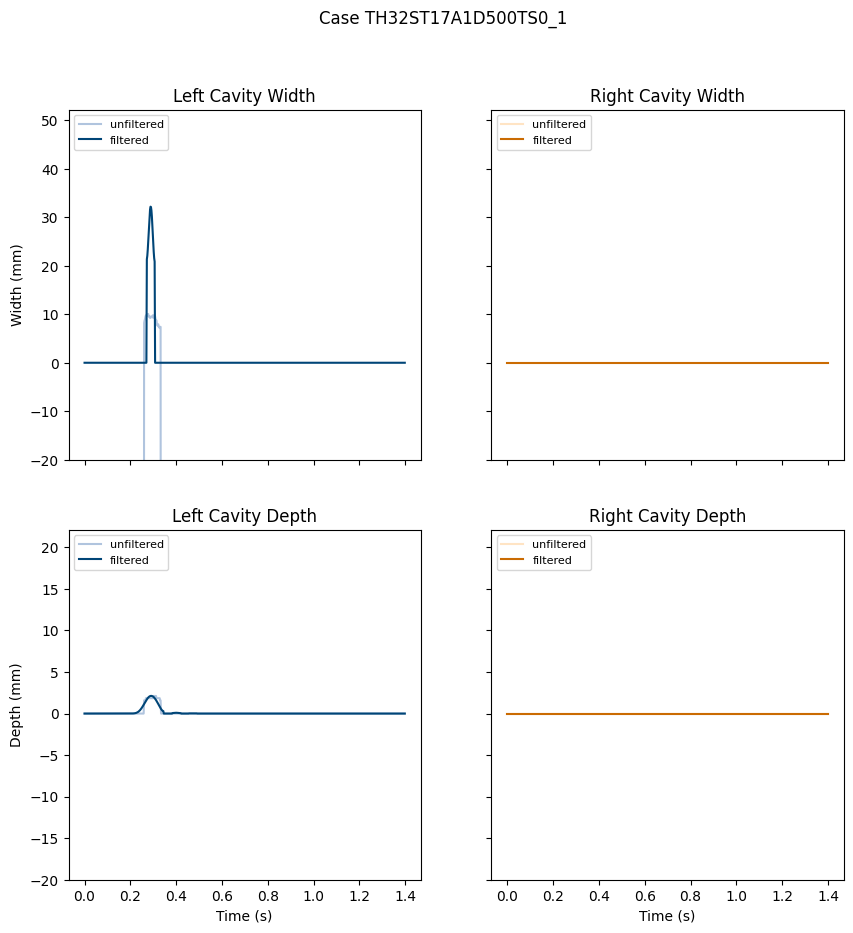

In [27]:
# plot cavity width and depth over time
fig, axs = plt.subplots(2, 2, sharex=True, sharey='row', figsize=[10, 10])

subtitles = ["Left Cavity Width", "Right Cavity Width", "Left Cavity Depth", "Right Cavity Depth"]
subtitles = np.array(subtitles).reshape((2, 2))
ylabels = ["Width (mm)", "Depth (mm)"]
ylim = [max(np.max(left_widths), np.max(right_widths)), max(np.max(left_depths), np.max(right_depths))]
colors = ["xkcd:prussian blue", "xkcd:browny orange", "lightsteelblue", "bisque"]

for row in range(len(unfiltered)):
    for col in range(len(unfiltered[0])):
        axs[row, col].plot(time, unfiltered[row][col], color=colors[col + 2], label='unfiltered')
        axs[row, col].plot(time, filtered[row][col], color=colors[col], label='filtered')
        axs[row, col].legend(loc=2, prop={'size' : 8})
        if row == 1:
            axs[row, col].set_xlabel("Time (s)")
        if col == 0:
            axs[row, col].set_ylabel(ylabels[row])
            axs[row, col].set_ylim(-20, ylim[row] + 20)
        axs[row, col].set_title(subtitles[row][col])

fig.suptitle("Case " + case_name)
plt.show()
    

In [28]:
# total area tracking
params2 = np.transpose(params)
cropped = unedited.copy()
cropped = cropped.crop(row_start=WATERLINE)
framelike = recording.frames[0][WATERLINE:]

mser_frames = []
for frame in range(len(lin_msers)):
    mser_frame = np.zeros_like(framelike)
    for mser in lin_msers[frame]:
        temp_mser = mser_to_array(mser, framelike)
        mser_frame = cv2.bitwise_or(temp_mser, mser_frame)
    
    boundary = np.zeros((10, mser_frame.shape[1]))
    boundary[-1][10:-10] = 255

    mser_frame = np.concatenate([boundary, mser_frame[1:]], axis=0)
    mser_frame[:, 0:50] = 0
    mser_frame[:, -51:-1] = 0
    mser_frames.append(mser_frame)

mser_frames = MOVE(frames=mser_frames)
mser_frames = mser_frames.dilate(kernel=cv2.MORPH_RECT, ksize=(12, 12))
mser_frames = mser_frames.erode(kernel=cv2.MORPH_RECT, ksize=(12, 12))
mser_frames = mser_frames.hole_filler()

filled = []
for frame in mser_frames.frames:
    temp_frame = frame[11:]
    temp_frame = np.concatenate([np.zeros((2, temp_frame.shape[1])), temp_frame], axis=0)
    filled.append(temp_frame)

left_areas = []
right_areas = []
for frame in range(len(filled)):
    left_area = 0
    right_area = 0
    for row in range(filled[0].shape[0]):
        for col in range(filled[0].shape[1]):
            if filled[frame][row][col] == 255:
                pixel = cropped.frames[frame][row][col]
                if col < fitfunc(row, *params2[frame]):
                    left_area += 1
                    cropped.frames[frame][row][col] = (min(pixel[0] + 100.0, 255), min(pixel[1] + 70.0, 255), min(pixel[2] + 20.0, 255))
                else:
                    right_area += 1
                    cropped.frames[frame][row][col] = (min(pixel[0] + 20.0, 255), min(pixel[1] + 70.0, 255), min(pixel[2] + 100.0, 255))
    left_areas.append(left_area)
    right_areas.append(right_area)

time, areas = calibrate([left_areas, right_areas], fullfin=FULLFIN, dim=3, times_width=True, return_time=True, unit='cm')

In [29]:
play_video(cropped)

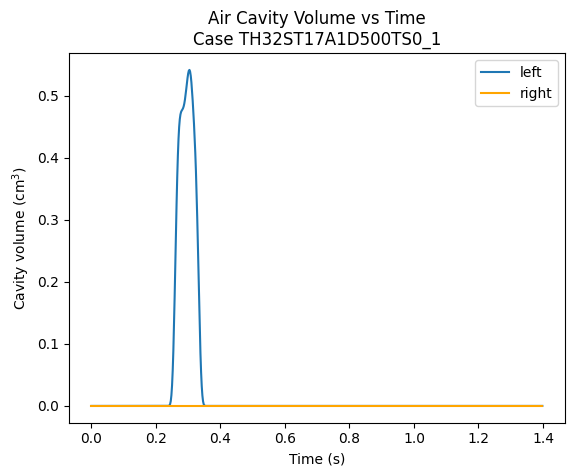

In [30]:
# plotting area
left_areas = areas[0]
right_areas = areas[1]

for i in range(2):
    left_areas = gaussian_filter1d(left_areas, sigma=2, radius=2)
    left_areas = gaussian_filter1d(left_areas, sigma=5, radius=3)
    right_areas = gaussian_filter1d(right_areas, sigma=2, radius=2)
    right_areas = gaussian_filter1d(right_areas, sigma=5, radius=3)

vol_plot = Figure()
ax = vol_plot.add_subplot()
ax.plot(time, left_areas, label="left")
ax.plot(time, right_areas, label="right", color="orange")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Cavity volume (cm$^3$)")
ax.legend()
ax.set_title("Air Cavity Volume vs Time\nCase " + case_name)

plt.plot(time, left_areas, label="left")
plt.plot(time, right_areas, label="right", color="orange")
plt.xlabel("Time (s)")
plt.ylabel(f"Cavity volume (cm$^3$)")
plt.legend()
plt.title("Air Cavity Volume vs Time\nCase " + case_name)
plt.show()

#### Force Data Processing

In [31]:
# mat loading
mat_fname = r"E:\TH32\TH32ST17A1D500\PROCESSED_TH32ST17A1D500TS0_1.mat"
mat_contents = scipy.io.loadmat(mat_fname, spmatrix=False)

In [37]:
# get start frame of cavity video
thresh = 100
frame_start = -1
for frame in range(1, 100):
    if abs(params2[frame - 1][-1] - params2[frame][-1]) > thresh:
        frame_start = frame
        break
if frame_start == -1:
    numbered = cropped.copy()
    for i in range(len(numbered.frames)):
        cv2.putText(numbered.frames[i], "Frame " + str(i), (1000, 300), cv2.FONT_HERSHEY_PLAIN, 1, 0, 2)

    play_video(numbered.frames[0:int(len(numbered.frames)/3)], ultraslow=True)
    frame_start = int(input("What was the first frame that the fin moved? "))
print(frame_start)

75


In [38]:
# mat data processing
vheader = mat_contents['processed_data']
Fy = vheader[0, 0]['Fy']
linpot = np.array(vheader[0, 0]['LPfilt'])
mat_time = vheader[0, 0]['time']
startIndex = vheader[0, 0]['StartIndex'][0, 0]

framerate = int(len(mat_time) / mat_time[-1][0])
start_point = fr1_to_fr2(0, 500, framerate, frame_start, startIndex)
end_point = fr1_to_fr2(len(cropped.frames), 500, framerate, frame_start, startIndex)
Fy = Fy[start_point:end_point]
linpot = linpot[start_point:end_point]
mat_time = mat_time[start_point:end_point] - (mat_time[start_point] - time[0])

In [39]:
# separate force data into air contact/water contact
last_vid_time = 0
med_count = 0
moving_right = True

left_air_times = []
left_air_forces = []
left_water_times = []
left_water_forces = []

right_air_times = []
right_air_forces = []
right_water_times = []
right_water_forces = []

for point in range(len(mat_time)):
	
    if point > 0:
        if linpot[point - 1] < linpot[point]:
            moving_right = True
        else:
            moving_right = False

    if last_vid_time < (len(time) - 1):
        if mat_time[point] > time[last_vid_time + 1]:
            last_vid_time += 1

    if moving_right:
        if contact_areas[1][last_vid_time] > 0:
            right_water_times.append(mat_time[point])
            right_water_forces.append(Fy[point])
        else:
            right_air_times.append(mat_time[point])
            right_air_forces.append(Fy[point])
    if not moving_right:
        if contact_areas[0][last_vid_time] > 0:
            left_water_times.append(mat_time[point])
            left_water_forces.append(Fy[point])
        else:
            left_air_times.append(mat_time[point])
            left_air_forces.append(Fy[point])


Text(0.5, 1.0, 'Y-direction Forces vs. Time')

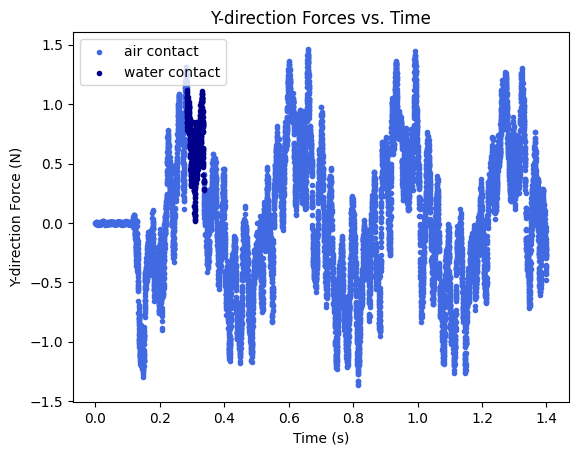

In [40]:
# plot force data with air/water contact information
air_times = left_air_times + right_air_times
air_forces = left_air_forces + right_air_forces
water_times = left_water_times + right_water_times
water_forces = left_water_forces + right_water_forces

plt.scatter(air_times, air_forces, label="air contact", marker=".", color="royalblue")
plt.scatter(water_times, water_forces, label="water contact", marker=".", color="darkblue")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Y-direction Force (N)")
plt.title("Y-direction Forces vs. Time")

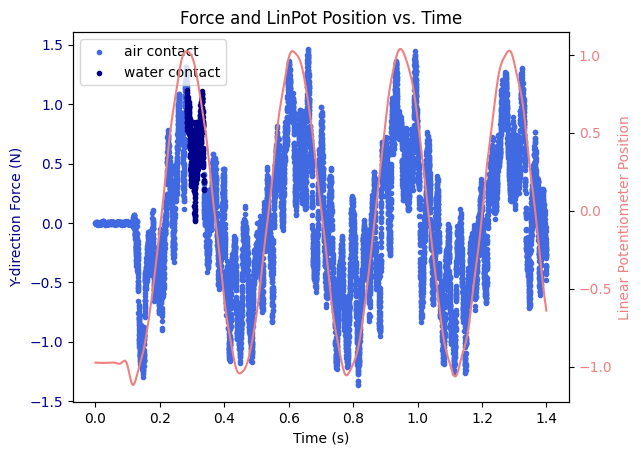

In [41]:
# linpot/force plot
fig, ax1 = plt.subplots()
color = 'darkblue'
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Y-direction Force (N)", color="darkblue")
ax1.scatter(air_times, air_forces, label="air contact", color='royalblue', marker=".")
ax1.scatter(water_times, water_forces, label="water contact", color="darkblue", marker=".")
ax1.tick_params(axis="y", labelcolor="darkblue")
ax1.legend()

ax2 = ax1.twinx()
color = 'lightcoral'
ax2.set_ylabel("Linear Potentiometer Position", color=color)
ax2.plot(mat_time, linpot, label="linpot position", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Force and LinPot Position vs. Time")
plt.show()

In [ ]:
# mat data loading for horizontal fin trials
h_mat_fname = r"C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\From Crush\PROCESSED_TH32ST17A3D900TS0_4.mat"
h_mat_contents = scipy.io.loadmat(h_mat_fname, spmatrix=False)

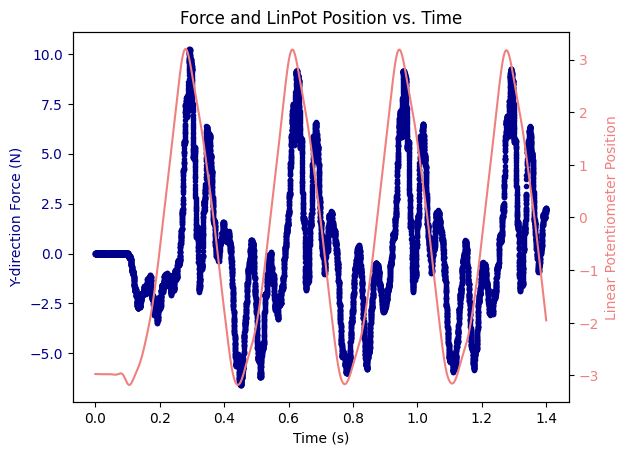

In [ ]:
# linpot/force processing & plotting for horizontal fin trials
h_header = h_mat_contents['processed_data']
h_Fy = h_header[0, 0]['Fy']
h_linpot = h_header[0, 0]['LPfilt']
h_mat_time = h_header[0, 0]['time']
h_startIndex = h_header[0, 0]['StartIndex'][0, 0]

h_framerate = int(len(h_mat_time) / h_mat_time[-1][0])
h_start_point = fr1_to_fr2(0, 500, h_framerate, frame_start, h_startIndex)
h_end_point = fr1_to_fr2(len(cropped.frames), 500, h_framerate, frame_start, h_startIndex)
h_Fy = h_Fy[h_start_point:h_end_point]
h_linpot = h_linpot[h_start_point:h_end_point]
h_mat_time = h_mat_time[h_start_point:h_end_point] - (h_mat_time[h_start_point] - time[0])

fig, ax1 = plt.subplots()
color = 'darkblue'
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Y-direction Force (N)", color="darkblue")
ax1.scatter(mat_time, Fy, color='darkblue', marker=".")
ax1.tick_params(axis="y", labelcolor="darkblue")

ax2 = ax1.twinx()
color = 'lightcoral'
ax2.set_ylabel("Linear Potentiometer Position", color=color)
ax2.plot(mat_time, linpot, label="linpot position", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Force and LinPot Position vs. Time")
plt.show()

#### PIV Data Processing

In [42]:
# load averaged data from piv processing
piv_fname = r"E:\TH32\TH32ST17A1D500\Averaged.mat"
piv_contents = scipy.io.loadmat(piv_fname, spmatrix=False)

In [43]:
# get cavity edges
edges = get_mser_edge(lin_msers, lin_bboxes, fin_removed.frames[0])

In [47]:
# check - show cavity edges on frame
frame = 150
MOVE.show(overlay.frames[frame])
test = overlay.frames[frame].copy()

for i in range(len(edges[frame][0])):
    cv2.circle(test, (edges[frame][0][i], edges[frame][1][i]), 1, (255, 255, 255), 1)

MOVE.show(test)

In [48]:
# find bottom of fin in cavity image
COUNT = 0
cv2.imshow("Click bottom of fin.", recording.frames[0][WATERLINE:])
cv2.setMouseCallback("Click bottom of fin.", distance_calibration)
cv2.waitKey(0)
cv2.destroyAllWindows()
print(PT1)

(578, 172)


In [49]:
# convert edges, fin position to mm
xtip = piv_contents['v_avg'][0, 0]['marker_x'][0][0]
ytip = piv_contents['v_avg'][0, 0]['marker_y'][0][0]

numrows = PT1[1] // 30
rows = np.linspace(0, PT1[1], numrows)
data_mm = np.array(mm_convert(np.array(rows), px_mm_cal, PT1[1], ytip, neg=True)).reshape((1, len(rows)))
data_mm = data_mm.astype(np.int8)

xlist = []
ylist = []
for frame in range(len(edges)):
    tempx = edges[frame][0]
    tempx = mm_convert(np.array(tempx), px_mm_cal, PT1[0], xtip)
    xlist.append(tempx)

    tempy = edges[frame][1]
    tempy = mm_convert(np.array(tempy), px_mm_cal, PT1[1], ytip, neg=True)
    ylist.append(tempy)  

    temp_centers = []
    for row in rows:
        temp_centers.append(fitfunc(row, *params2[frame]))
    temp_centers = mm_convert(np.array(temp_centers), px_mm_cal, PT1[0], xtip)
    data_mm = np.concatenate([data_mm, temp_centers.reshape(1, len(temp_centers))], axis=0)

In [50]:
print(mm_convert(np.array([-1]), px_mm_cal, PT1[0], xtip))

[-58.53108637]


In [51]:
print(rows)

[  0.  43.  86. 129. 172.]


In [52]:
print(data_mm[0])

[-11. -22. -33. -45. -56.]


In [53]:
print(piv_contents['v_avg'][0, 0]['marker_y'][0])

[-56.59401552 -47.75027706 -38.17510159 -27.32914666 -16.88215737]


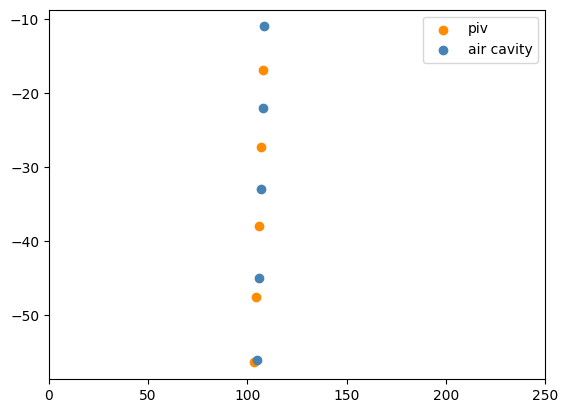

In [54]:
# if something is sketchy, can visualize fin positions to make sure they (roughly) align
fnum = 650

markx = piv_contents['v_avg'][0, fnum]['marker_x'][0]
marky = piv_contents['v_avg'][0, fnum]['marker_y'][0]
plt.scatter(markx, marky, color='darkorange', label="piv")
plt.scatter(data_mm[fnum + 1], data_mm[0], color='steelblue', label="air cavity")
#plt.ylim(-200, 0)
plt.xlim(0, 250)
plt.legend()
plt.show()

In [59]:
# prepare to save data - create arrays, set directory & filenames
save_x = np.array(xlist)
save_y = np.array(ylist)

if len(xlist[0]) > 0:
    crow = np.zeros_like(save_y[0]).reshape(1, len(save_y[0]))
    crow = mm_convert(crow, px_mm_cal, PT1[1], ytip, neg=True)
    save_y = np.concatenate((crow, save_y), axis=0)
    print("yes")
else:
    save_x = -1 * np.ones((len(overlay.frames), 1))
    save_y = np.ones((len(overlay.frames), 1))
    save_y[0][0] = mm_convert(0, px_mm_cal, PT1[1], ytip, neg=True)

savedir = r'E:\TH32\TH32ST17A1D500'
xfile = 'overlay_x_' + case_name + '.csv'
yfile = 'overlay_y_' + case_name + '.csv'
finfile = 'fin_pos_' + case_name + '.csv'

yes


In [60]:
# actually save data
np.savetxt(os.path.join(savedir, xfile), save_x, fmt='%f', delimiter=',')
np.savetxt(os.path.join(savedir, yfile), save_y, fmt='%f', delimiter=',')
np.savetxt(os.path.join(savedir, finfile), data_mm, fmt='%f', delimiter=',')

##### Cavity/vortex distance

In [61]:
# minimally filtered vorticity frames
blank = []
for frame in piv_contents['v_avg'][0]:
    vort = np.array(frame['w']).transpose()[20:]
    vort = np.where(np.isnan(vort), 0, vort)
    vort = (np.absolute(vort) / 300)
    blank.append(vort)

blank = MOVE(frames=blank)
blank = blank.ranger(minval=0.1, maxval=1)
blank = blank.erode(kernel=cv2.MORPH_RECT, ksize=(3, 3))
blank = blank.dilate(kernel=cv2.MORPH_RECT, ksize=(3, 3))

# produce filtered/marked frames, find distances
vnearest = []
vdist = []
vdist_long = []
vtemp = []
for frame in range(len(piv_contents['v_avg'][0])):
    vavg = piv_contents['v_avg'][0, frame]
    xmm = piv_contents['v_avg'][0, 0]['x'][0]
    ymm = piv_contents['v_avg'][0, 0]['y'][0]

    vort = np.array(vavg['w']).transpose()[20:]
    vort = np.where(np.isnan(vort), 0, vort)
    vort = (np.absolute(vort) / 300)
    vort = cv2.inRange(vort, lowerb=0.15, upperb=1)
    vort = cv2.erode(vort, kernel=cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))
    vort = cv2.dilate(vort, kernel=cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))

    count, labels, stats, centers = cv2.connectedComponentsWithStats(vort, connectivity=4, ltype=cv2.CV_32S)
    vtip = -1
    negx = mm_convert(np.array([-1]), px_mm_cal, PT1[0], xtip)
    if count > 1:
        mindist = 1000
        finx = data_mm[frame + 1][-1] 
        finy = data_mm[0][-1]
        for j in range(1, len(centers)):
            center = centers[j]
            centerx = xmm[int(center[0])]
            centery = ymm[int(center[1] + 20)]
            if math.dist([centerx, centery], [finx, finy]) < mindist:
                mindist = math.dist([centerx, centery], [finx, finy])
                vtip = j

        mindist = 1000
        for k in range(len(xlist[frame])):
            cavx = xlist[frame][k]
            if not cavx == negx:
                cavy = ylist[frame][k]
                centerx = xmm[int(centers[vtip][0])]
                centery = ymm[int(centers[vtip][1] + 20)]
                old = mindist
                mindist = min(mindist, math.dist([centerx, centery], [cavx, cavy]))
                #if old != mindist:
                    #print(frame, mindist, centerx, centery, cavx, cavy)

# problem i think--maybe appending 1000s because multiple vortices but no cavity?
        if mindist < 1000:
            if len(vtemp) == 0 or vtemp[0] != -1:
                vtemp.append(mindist)
            else:
                vdist.append(vtemp)
                vtemp = [mindist]
            vdist_long.append(mindist)
        else:
            if len(vtemp) == 0 or vtemp[0] == -1:
                vtemp.append(-1)
            else:
                vdist.append(vtemp)
                vtemp = [-1]
            vdist_long.append(-1) 

    else:
        if len(vtemp) == 0 or vtemp[0] == -1:
            vtemp.append(-1)
        else:
            vdist.append(vtemp)
            vtemp = [-1]
        vdist_long.append(-1)

    labels = np.array(labels).astype(np.uint8)
    lapels = np.where(labels != 0, 255, 0).astype(np.uint8)
    lapels = cv2.cvtColor(lapels, cv2.COLOR_GRAY2BGR)
    if vtip > 0:
        xpos = int(centers[vtip][0])
        ypos = int(centers[vtip][1])
        lapels[(ypos-1):(ypos+1),(xpos-1):(xpos+1)] = (0, 0, 255)
    vnearest.append(lapels)
vdist.append(vtemp)

In [62]:
# unmarked & marked vorticity video comparison
# yes, they are supposed to be that small
blank_ = []
for frame in blank.frames:
    blank_.append(cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR))
compare_videos(blank_, vnearest)

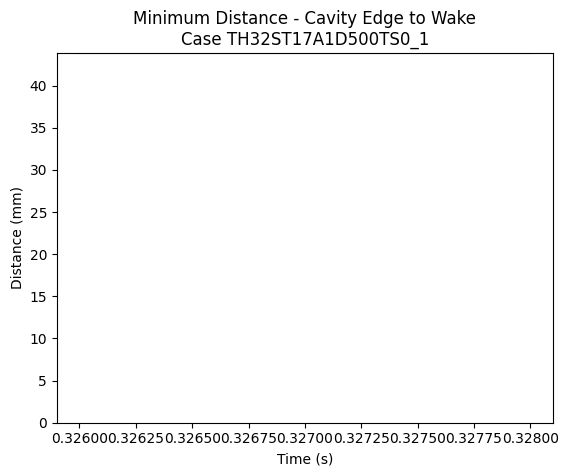

In [63]:
# smooth vortex/cavity distance data and plot
vfinal = []
for temp in vdist:
    for i in range(3):
        temp = gaussian_filter1d(temp, sigma=2, radius=5)
    vfinal.extend(temp)

off = -1*(len(time) - len(vfinal))
vtime = time[:off].copy().tolist()
i = 0
while i < len(vfinal):
    if vfinal[i] == -1:
        vfinal.pop(i)
        vtime.pop(i)
        i -= 1
    i += 1

vdist_plot = Figure()
ax = vdist_plot.add_subplot()
ax.plot(vtime, vfinal)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Distance (mm)")
ax.set_ylim(0)
ax.set_title("Minimum Distance - Cavity Edge to Wake\nCase " + case_name)

plt.clf()
plt.plot(vtime, vfinal)
plt.xlabel("Time (s)")
plt.ylabel("Distance (mm)")
plt.ylim(0)
plt.title("Minimum Distance - Cavity Edge to Wake\nCase " + case_name)
plt.show()

#### Save Data

In [64]:
# save data

# ----- TO UPDATE -----
update_savedir = False # True if you want to save the data to a different directory than the one the video is in
if update_savedir: # update below to whatever you want
    savedir = r"C:\Users\aatid\Downloads\Interesting Air Cavity Data\Interesting Air Cavity Data\From Crush\TH32ST17A3D1000TS0\cavity_params\TH32ST17A3D1000TS0_3_params"
# ---------------------

base = np.zeros_like(time)

# storing processing parameters, just in case
misc = np.zeros_like(time)
misc_units = np.where(base == 0, "", base)
misc_labels = np.where(base == 0, "",  base)
miscdat = [px_mm_cal, ALPHA, BETA, WATERLINE, REMOVAL_KSIZE[0], REMOVAL_KSIZE[1], RETRIEVAL_KSIZE[0], RETRIEVAL_KSIZE[1], VERT_THRESHOLD, AREA_THRESHOLD, HTHRESH, VTHRESH]
labeldat = ["distance calibration", "alpha", "beta", "waterline", "removal ksize y", "removal ksize x", "retrieval ksize y", "retrieval ksize x", "mser vert thresh", "mser area thresh", "wave hthresh", "wave vthresh"]
unitdat = ["px/mm", "", "", "px", "px", "px", "px", "px", "frac", "frac", "px", "px"]
for i in range(len(miscdat)):
    misc[i] = miscdat[i]
    misc_labels[i] = labeldat[i]
    misc_units[i] = unitdat[i]

vfin = np.concatenate((np.array(vdist_long).reshape(1, len(vdist_long)), np.zeros((1, abs(off)))), axis=1)

mm = np.where(base == 0, "mm", base)
s = np.where(base == 0, "s", base)
mm3 = np.where(base == 0, "cm^3", base)
header = ["time", "time unit", "lwidth", "ldepth", "lfwhm", "rwidth", "rdepth", "rfwhm", "w d fwhm unit", "lvol", "rvol", "vol unit", "cav wake dist", "dist unit", "misc", "mist label", "misc unit"]
savedata = np.array([time, s, left_widths, left_depths, left_fwhm, right_widths, right_depths, right_fwhm, mm, left_areas, right_areas, mm3, vfin[0], mm, misc, misc_labels, misc_units])

savedata = savedata.transpose()
header = np.array(header).reshape((1, len(header)))
savedata = np.concatenate([header, savedata], axis=0)

In [65]:
np.savetxt(os.path.join(savedir, case_name + "_cavity_params.csv"), savedata, fmt='%s', delimiter=',')
np.savetxt(os.path.join(savedir, case_name + "_fit_params.csv"), params2, delimiter=',')
vdist_plot.savefig(os.path.join(savedir, case_name + "_cav_wake_dist.png"))
vol_plot.savefig(os.path.join(savedir, case_name + "_cav_volume.png"))
fig.savefig(os.path.join(savedir, case_name + "_cav_width_depth.png"))

### Junkyard
Tried, didn't work out, don't want to delete entirely in case they're useful in the future

In [ ]:
# error approximation

# frame = 0
# width_err = 0
# area_err = 0

# while True:
#     xs = []
#     ys = []
#     MOVE.show(display_frames[frame])

#     get = input("Get points? [y / n]")
#     if get == "y":
#         for i in range(4):
#             COUNT = 0
#             cv2.imshow("Click bottom of fin.", display_frames[frame])
#             cv2.setMouseCallback("Click bottom of fin.", get_points)
#             cv2.waitKey(0)
#             cv2.destroyAllWindows()
#             cv2.circle(display_frames[frame], PT1, 2, (0, 0, 255), 2)
#             xs.append(PT1[0])
#             ys.append(PT1[1])

#         done = input("Done? [y / n]")
#         if done == "y":
#             x_up = [xs.pop(ys.index(min(ys)))]
#             y_up = [ys.pop(ys.index(min(ys)))]
#             x_up.append(xs.pop(ys.index(min(ys))))
#             y_up.append(ys.pop(ys.index(min(ys))))

#             y_avg = int((ys[0] + ys[1])/2)
#             x_avg = int((x_up[0] + x_up[1]) / 2)
    
#             width_err = abs(xs[0] - xs[1])
#             area_err = 0.5 * abs(x_up[0] - x_up[1]) * (y_avg)

#             cv2.line(display_frames[frame], (x_up[0], 0), (x_up[1], 0), (255, 0, 0), 2)
#             cv2.line(display_frames[frame], (x_avg, 0), (x_avg, y_avg), (255, 0, 0), 2)
#             cv2.line(display_frames[frame], (xs[0], y_avg), (xs[1], y_avg), (0, 0, 255), 2)

#             MOVE.show(display_frames[frame])
#             print(frame)
#             break
#     frame += int(input("How many frames to move? "))

In [ ]:
# # create spline mask (doesn't work well)

# if use_auto == 'y':
#     a, b, lowest_point = fin_contoured.lin_tracking()
#     output_frames, display_frames = cropped.create_lin_mask(fin_removed, a, b, lowest_point, 15, display = True)
# else:
#     numbered = cropped.copy()
#     for i in range(len(numbered.frames)):
#         cv2.putText(numbered.frames[i], "Frame " + str(i), (1000, 300), cv2.FONT_HERSHEY_PLAIN, 1, 0, 2)

#     play_vid = input("Play video to determine first period? [y / n] ")
#     if play_vid == 'y':
#         play_video(numbered.frames[0:550], ultraslow=True)
#     frame_start = int(input("What was the first frame that the fin moved? "))
#     frame_end = int(input("What was the end of the first period? "))
#     segments = int(input("How many segments would you like to use to track the fin? 1 should work except in very flexible cases. "))

#     keyframes = np.linspace(frame_start, frame_end, 7)
#     extended = [frame_end + 20, frame_end + 60, frame_end + 100, frame_end + 150, frame_end + 200, frame_end + 250, frame_end + 300]
#     keyframes = np.concatenate([keyframes, extended]).astype(np.uint)

#     a_list = np.zeros((segments, len(keyframes)))
#     b_list = []
#     min_x = 1200
#     max_x = 0

#     for j in range(len(keyframes)):
#         frame = keyframes[j]
#         active_frame = cropped.frames[frame].copy()
#         h_divs = np.linspace(0, 350, segments, endpoint=False).astype(np.uint)
#         for segment in range(segments):
#             cv2.line(active_frame, (0, h_divs[segment]), (active_frame.shape[1] - 1, h_divs[segment]), 0, 1)

#         # first segment
#         cv2.cvtColor(active_frame, cv2.COLOR_GRAY2BGR)
#         cv2.imshow("Click top of fin.", active_frame)
#         cv2.setMouseCallback("Click top of fin.", get_points)
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
#         cv2.circle(active_frame, (PT1[0], PT1[1]), 2, (255, 255, 255), 2)
#         if PT1[0] < min_x:
#             min_x = PT1[0]
#         if PT1[0] > max_x:
#             max_x = PT1[0]

#         for segment in range(segments):
#             COUNT = 1
#             cv2.imshow("Click next line or bottom of fin.", active_frame)
#             cv2.setMouseCallback("Click next line or bottom of fin.", get_points)
#             cv2.waitKey(0)
#             cv2.destroyAllWindows()
#             cv2.circle(active_frame, (PT2[0], PT2[1]), 2, (255, 255, 255), 2)

#             x = [PT1[1], PT2[1]]
#             y = [PT1[0], PT2[0]]
#             yerr = [5, 5]

#             if segment > 0:
#                 x = [0, PT2[1] - PT1[1]]
#                 y = [0, PT2[0] - PT1[0]]
#                 (popt, pcov) = curve_fit(slopefit, x, y, sigma=yerr, absolute_sigma=True)
#                 a_list[segment][j] = popt[0]
#             else:
#                 (popt, pcov) = curve_fit(linfit, x, y, sigma=yerr, absolute_sigma=True)
#                 a_list[segment][j] = popt[0]
#                 b_list.append(popt[1])

#             PT1 = PT2

In [ ]:
# # applying linear mask

# if use_auto != 'y':
#     #h_divs = np.linspace(0, 350, segments, endpoint=False).astype(np.uint)
#     #h_divs = np.concatenate((h_divs, [350])).astype(np.uint)
#     #(save_a, save_b) = lin_to_cos(keyframes, a_list[0], b_list, max_x, min_x, frame_start, frame_end)
#     (save_a, save_b) = lin_to_cos(keyframes, a_list, b_list, max_x, min_x, frame_start, frame_end)
#     output_frames, display_frames = cropped.create_lin_mask(fin_removed, save_a, save_b, 350, 20, display=True, display_vid=cropped, display_color = (0, 0, 0))

#     '''for i in range(1, segments):
#         a = lin_to_cos(keyframes, a_list[i], b_list[i], max_x, min_x, frame_start, frame_end, slope_only=True)
#         row = h_divs[i]
#         b = (save_a * row) + save_b - (a * row)
#         save_a = a
#         save_b = b
#         temp_output, temp_display = cropped.create_lin_mask(fin_removed, a, b, 350, 25, display=True, display_vid=cropped, display_color = (0, 0, 0))
#         for frame in range(len(output_frames)):
#             output_frames[frame] = np.concatenate((output_frames[frame][:h_divs[i]], temp_output[frame][h_divs[i]:]), axis=0)
#             display_frames[frame] = np.concatenate((display_frames[frame][:h_divs[i]], temp_display[frame][h_divs[i]:]), axis=0)
#     output_frames = np.concatenate((fin_removed[0:frame_start], output_frames[frame_start:]), axis=0)'''

# lin_mask = MOVE(frames=output_frames)
# lin_masked = dupe.bitwise_and(lin_mask)
# lin_masked = MOVE(frames=lin_masked)
# lin_masked = lin_masked.median_blur(ksize=5)

In [ ]:
# old method - mask applied to entire frame. here for comparison if desired
#masked = cropped.bitwise_and(fin_removed)
#masked = MOVE(frames=masked)
#masked = masked.median_blur(ksize=5)
#play_video(masked)

#(og_msers, og_bboxes) = masked.mser_track(mser=mser, vert_threshold=0.35, area_threshold=0.5)
#play_video(og_msers)

#og_vid = MOVE(vid_path)
#cropped2 = og_vid.crop(row_start=WATERLINE)
#cropped2 = bbox_overlay(cropped2, og_bboxes, color = (84, 121, 255), width=2)
#play_video(cropped2)

In [53]:
# figure out changes in strokes from predicted/tracked position instead of linpot data

# import statistics

# lead_pos = params[-1]
# for i in range(5):
#     lead_pos = gaussian_filter1d(lead_pos, sigma=3, radius=5)

# strokes = []
# temp_stroke = []
# instroke = True
# for i in range(frame_start, len(lead_pos) - 5):
#     if lead_pos[i - 5] > lead_pos[i] and lead_pos[i + 5] > lead_pos[i]:
#         temp_stroke.append(time[i])
#         instroke = False
#     elif lead_pos[i - 5] < lead_pos[i] and lead_pos[i + 5] < lead_pos[i]:
#         temp_stroke.append(time[i])
#         instroke = False
#     else:
#         if not instroke:
#             strokes.append(temp_stroke)
#             temp_stroke = []
#             instroke = True

# medians = []
# for stroke in strokes:
#     medians.append(statistics.median(stroke))

# temp_time = time[frame_start:]
# temp_lead_pos = lead_pos[frame_start:]

# plt.plot(temp_time, temp_lead_pos)
# plt.vlines(medians, color='orange', ymin=(min(lead_pos) - 10), ymax=(max(lead_pos) + 10))
# plt.xlabel("Time (s)")
# plt.ylabel("Leading Edge Position (px)")
# plt.title("Leading Edge Position vs. Time")
# plt.show()